## Let's run intron clustering to annotate alternative splicing events given observed junctions in our cells 

In [1]:
# Load LeafletSC 
import LeafletSC
from LeafletSC.clustering.find_intron_clusters import main as find_intron_clusters
from LeafletSC.clustering.prepare_model_input import main as prep_model_input
from LeafletSC.clustering.find_intron_clusters import visualize_local_events

import os
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix

# turn this into AnnData object 
import anndata as ad
from scipy.sparse import csr_matrix
from scipy.sparse import coo_matrix

# Define path that contains junction files
juncs_path = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/"
print("The junctions are loaded from the following path: " + juncs_path) 

# print the files in the path 
print("The files in the path are: " + str(os.listdir(juncs_path)))

# define path for saving the output data 
output_path = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet"

# we provide a gtf file for the human genome as well to make better sense of the junctions that are detected in cells
# please replace with the path to the gtf file on your system
gtf_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/gencode.vM19/genes/genes.gtf" 

The junctions are loaded from the following path: /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/
The files in the path are: ['3_month', '24_month', '21_month', '18_month']


In [2]:
!hostname

pe2cc2-073.c.nygenome.org


In [3]:
# metadata file
metadata = "/gpfs/commons/projects/knowles_singlecell_splicing/TabulaSenis/data/AWS/metadata/tabula-muris-senis-full-metadata.csv"
metadata = pd.read_csv(metadata)
metadata.head()

/scratch/ipykernel_26025/2948469132.py:3: DtypeWarning: Columns (3,5,14) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(metadata)


,index,age,batch,cell,cell_ontology_class,cell_ontology_id,free_annotation,method,mouse.id,n_counts,n_genes,sex,subtissue,tissue,tissue_free_annotation,louvain,leiden
0,AAACCTGCAGGGTACA-1-0-0-0-0,24m,0,MACA_24m_M_TONGUE_60_AAACCTGCAGGGTACA,keratinocyte,NaN,filiform,droplet,24-M-60,5482.0,2107.0,male,NaN,Tongue,Tongue,5,3
1,AAACCTGCAGTAAGCG-1-0-0-0-0,24m,0,MACA_24m_M_TONGUE_60_AAACCTGCAGTAAGCG,keratinocyte,NaN,suprabasal,droplet,24-M-60,21855.0,3481.0,male,NaN,Tongue,Tongue,27,31
2,AAACCTGTCATTATCC-1-0-0-0-0,24m,0,MACA_24m_M_TONGUE_60_AAACCTGTCATTATCC,keratinocyte,NaN,suprabasal,droplet,24-M-60,10942.0,2599.0,male,NaN,Tongue,Tongue,27,31
3,AAACGGGGTACAGTGG-1-0-0-0-0,24m,0,MACA_24m_M_TONGUE_60_AAACGGGGTACAGTGG,keratinocyte,NaN,suprabasal differentiating,droplet,24-M-60,20665.0,3468.0,male,NaN,Tongue,Tongue,24,11
4,AAACGGGGTCTTCTCG-1-0-0-0-0,24m,0,MACA_24m_M_TONGUE_60_AAACGGGGTCTTCTCG,keratinocyte,NaN,suprabasal differentiating,droplet,24-M-60,12925.0,3189.0,male,NaN,Tongue,Tongue,5,3


In [4]:
# subset metadata to only facs under method 
metadata = metadata[metadata['method'] == 'facs']
metadata.shape

(110824, 17)

Text(0, 0.5, '# of genes detected in cell')

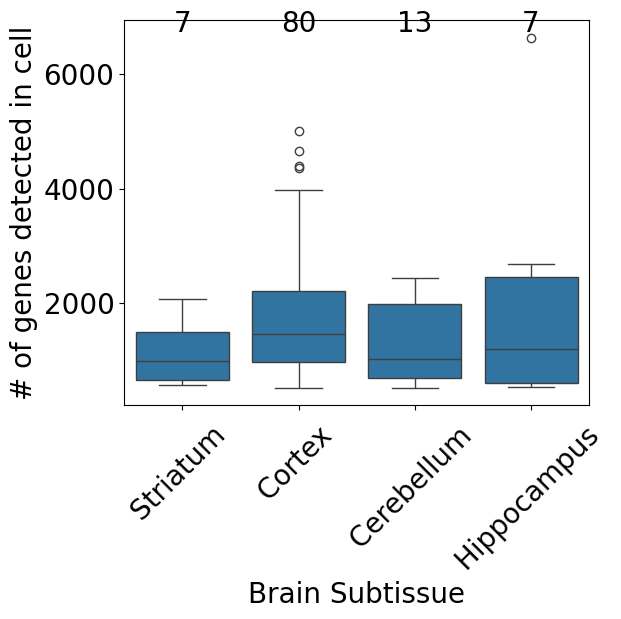

In [5]:
# make a histogram of n_genes across the following cells 
astros = metadata[(metadata['cell_ontology_class'] == 'astrocyte') & (metadata['age'] == "18m")]

# plot violin plots showing n_genes coloured by subtissue 
plt.figure(figsize=(6, 5))

# increase font of everything 
plt.rcParams.update({'font.size': 20})
sns.boxplot(x='subtissue', y='n_genes', data=astros)
plt.xticks(rotation=45)

# print number of cells in each group on top of corresponding boxplot 
for i, group in enumerate(astros['subtissue'].unique()):
    n = len(astros[astros['subtissue'] == group])
    plt.text(i, astros['n_genes'].max(), n, ha='center', va='bottom')

# xlab Brain Subtissue 
plt.xlabel('Brain Subtissue')

# ylab to be Number of genes detected 
plt.ylabel('# of genes detected in cell')

In [6]:
brain_only = metadata[metadata['tissue'].isin(['Brain_Non-Myeloid', 'Brain_Myeloid'])]
brain_only.cell_ontology_class.value_counts()

cell_ontology_class
microglial cell                    13268
endothelial cell                    2232
oligodendrocyte                     2094
astrocyte                            592
neuron                               484
brain pericyte                       484
oligodendrocyte precursor cell       312
macrophage                           312
interneuron                          240
neuroepithelial cell                 151
CD8-positive, alpha-beta T cell      104
medium spiny neuron                  103
neuronal stem cell                    97
T cell                                67
ependymal cell                        55
Bergmann glial cell                   54
mature NK T cell                      17
Name: count, dtype: int64

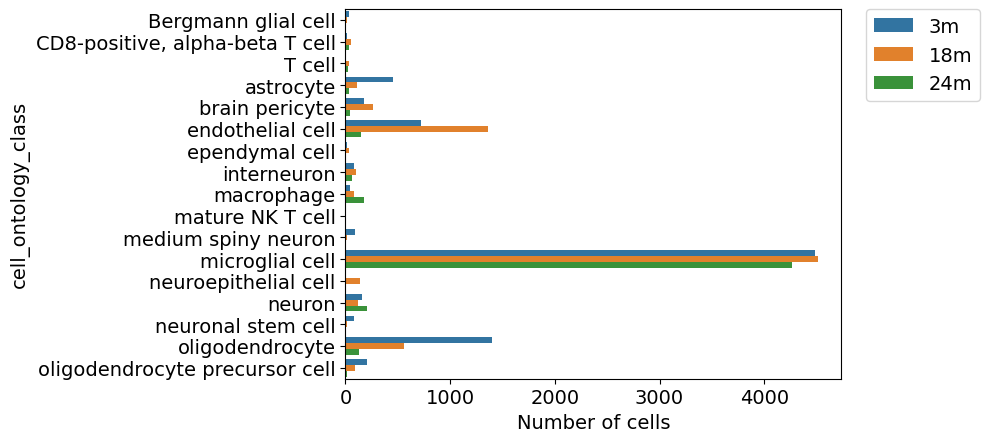

In [7]:
age_tissue = brain_only.groupby(['age', 'cell_ontology_class']).size()

# make a dataframe and keep only Brain_Non-Myeloid and Brain_Myeloid cells 
age_tissue = age_tissue.reset_index()
age_tissue = age_tissue.rename(columns={0: 'count'})

# specify order of cateogries for age column, 3m, 18, 24m
age_tissue['age'] = pd.Categorical(age_tissue['age'], categories=['3m', '18m', '24m']) 

# make barplot using age_tissue 
# increase font size globally for all plots 
plt.rcParams.update({'font.size': 14})

# make barplot so cell_only_class are along y-axis
sns.barplot(x='count', y='cell_ontology_class', hue='age', data=age_tissue)

# add yaxis label
plt.xlabel('Number of cells')

# put legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


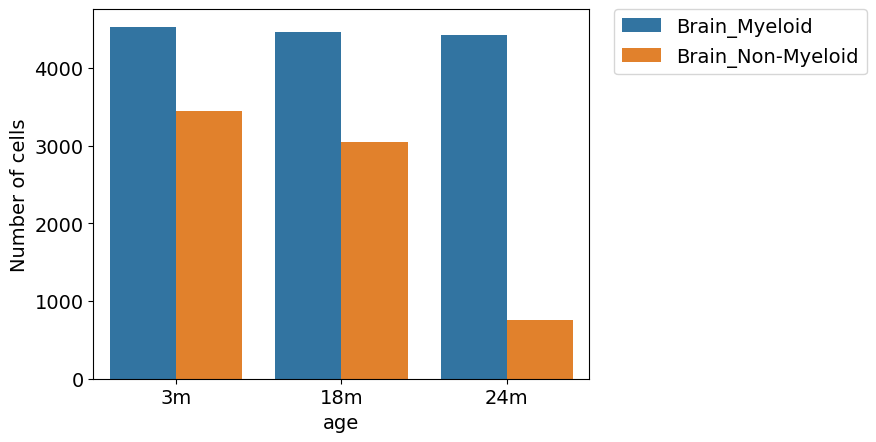

In [8]:
age_tissue = metadata.groupby(['age', 'tissue']).size()
# make a dataframe and keep only Brain_Non-Myeloid and Brain_Myeloid cells 
age_tissue = age_tissue.reset_index()
age_tissue = age_tissue[age_tissue['tissue'].isin(['Brain_Non-Myeloid', 'Brain_Myeloid'])]
age_tissue = age_tissue.rename(columns={0: 'count'})

# specify order of cateogries for age column, 3m, 18, 24m
age_tissue['age'] = pd.Categorical(age_tissue['age'], categories=['3m', '18m', '24m']) 

# make barplot using age_tissue 
# increase font size globally for all plots 
plt.rcParams.update({'font.size': 14})

sns.barplot(x='age', y='count', hue='tissue', data=age_tissue)

# add yaxis label
plt.ylabel('Number of cells')

# put legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [9]:
# print number of cells in each age group mouse and make barplot 
# make age column categories in order 3m, 18m, 21m, 24m 
metadata['age'] = metadata['age'].astype('category')

### Let's first define some parameters for the analysis

In [10]:
# get cell ids from metadata "index" column by keeping everything before the ".mm10"
metadata['cell_id'] = metadata['index'].str.split('.').str[0]

In [11]:
cell_ids_brain = metadata[metadata['tissue'].isin(['Brain_Non-Myeloid', 'Brain_Myeloid'])]['cell_id']
cell_ids_brain = cell_ids_brain.values

# list the first 5 files or folders in juncs_path
all_files = os.listdir(juncs_path)
print(all_files)

['3_month', '24_month', '21_month', '18_month']


In [12]:
all_junc_files = []

# List all subdirectories in juncs_path
all_dirs = os.listdir(juncs_path)
print("Subdirectories found:", all_dirs)

# Loop through each subdirectory
for dir in all_dirs:
    dir_path = os.path.join(juncs_path, dir)
    
    # Check if it's actually a directory
    if os.path.isdir(dir_path):
        print(dir_path)
        junc_files = os.listdir(dir_path)
        
        # Construct full paths and include the subdirectory information
        junc_files = [os.path.join(dir_path, x) for x in junc_files]
        
        # Add these files to the main list
        all_junc_files.extend(junc_files)

# Now flatten the list (though it's already flat due to `extend`)
# all_junc_files = [item for sublist in all_junc_files for item in sublist]  # This step is no longer needed

# Convert cell_ids_brain to a set for faster membership testing
cell_ids_brain_set = set(cell_ids_brain)

# Filter the files using the set for faster lookup and keep the correct paths
portion_in_list2 = [x for x in all_junc_files if os.path.splitext(os.path.basename(x))[0] in cell_ids_brain_set]

# Construct final paths by appending "/junctions_with_barcodes.bed" to each matching file
portion_in_list2 = [x + "/junctions_with_barcodes.bed" for x in portion_in_list2]

# Print the resulting paths
print("Final paths with correct subdirectory context:")
portion_in_list2[0]

Subdirectories found: ['3_month', '24_month', '21_month', '18_month']
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/3_month
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/24_month
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/21_month
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month
Final paths with correct subdirectory context:


'/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/24_month/L19_B000841_S283_L001/junctions_with_barcodes.bed'

In [13]:
# junc_files defines a path for where junction files can be found, in this case, the path is defined above
junc_files = portion_in_list2
print(len(junc_files), len(cell_ids_brain))

12657 20666


In [14]:
# define additional parameters 
sequencing_type = "single_cell"

# ensure output files are to be saved in output_path 
output_file = output_path + "/all_ages_brain_intron_clusters"
junc_bed_file= output_path + "/all_ages_brain_intron_clusters.bed" # you can load this file into IGV to visualize the junction coordinates 
min_intron_length = 50
max_intron_length = 500000
threshold_inc = 0.01 
min_junc_reads = 10
min_num_cells_wjunc = 100
keep_singletons = False # ignore junctions that do not share splice sites with any other junction (likely const)
junc_suffix = "*with_barcodes.bed" # depends on how you ran regtools 

### Run intron clustering 

In [ ]:
all_juncs_df = find_intron_clusters(junc_files=junc_files, gtf_file=gtf_file, output_file=output_file, 
                       sequencing_type=sequencing_type, junc_bed_file=junc_bed_file, 
                       threshold_inc=threshold_inc, min_intron = min_intron_length,
                       max_intron=max_intron_length, min_junc_reads=min_junc_reads,
                       singleton=keep_singletons,
                       junc_suffix=junc_suffix, min_num_cells_wjunc=min_num_cells_wjunc, filter_shared_ss=True, 
                       run_notebook = True)

In [ ]:
# load bed file 
import pandas as pd
juncs_bed = pd.read_csv(junc_bed_file, sep="\t", header=None)
# remove columns 3 and 4 
juncs_bed = juncs_bed.drop(columns=[3, 4])
juncs_bed.columns = ["Chromosome", "Start", "End", "Strand", "junction_id", "Start_b", "End_b", "gene_id", "gene_name", "transcript_id", "exon_id"]

# cmobine with all_juncs_df and prep df for visualization 
dat_vis = all_juncs_df[["chrom", "chromStart", "chromEnd", "strand", "intron_length", "counts_total", "junction_id", "Cluster"]]
dat_vis = dat_vis.drop_duplicates()
# merge dat_vis with juncs_bed using all common columns 
dat_vis = dat_vis.merge(juncs_bed, how="left", on=["junction_id"])

In [ ]:
#from LeafletSC.clustering.find_intron_clusters import visualize_junctions
junc_id = all_juncs_df.junction_id.sample(1).values[0]
j = junc_id
visualize_local_events(dat_vis, j, p_usage_ratio=True)

In [ ]:
# get average number of junctions per cluster here 
avg_juncs_per_cluster = dat_vis.groupby("Cluster").size().mean()
print("The average number of junctions per cluster is: " + str(avg_juncs_per_cluster))

### Now let's convert the intron clusters to a format that can be used by LeafletSC

In [15]:
intron_clusters = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/all_ages_brain_intron_clusters_50_500000_10_20240911_single_cell.gz" # path to the intron clusters file
output_file = output_path + "all_ages_brain_intron_clusters" # what you want to name the output file
has_genes = "yes" # since we used a gtf file to obtain the intron clusters, we can set this to yes
chunk_size = 5000 # number of junctions to process at a time from the intron clusters files
# metadata = None # can replace with path, if metadata is available for cells (cell type, origin, library ID...)

In [16]:
prep_model_input(intron_clusters, output_file, has_genes, chunk_size, None)

The intron clusters file you provided is /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/all_ages_brain_intron_clusters_50_500000_10_20240911_single_cell.gz, reading in chunks of 5000 lines
Processing intron clusters


1518it [01:31, 16.55it/s]


Done processing intron clusters
The number of intron clusters evaluated is 2839
The number of junctions evaluated is 7624
The number of cells evaluated is 12652
The number of clusters with only one junction is 0
A gtf file was used to generate intron clusters
The number of total cells evaluated is 12652
The number of cells per cell type is:
cell_type
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/A10_B000176_B008056_S10/junctions_with_barcodes.bed     1
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/A10_B001060_B009250_S214/junctions_with_barcodes.bed    1
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/A10_B001061_B009251_S298/junctions_with_barcodes.bed    1
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/A10_B001244_B006737_S10/junctions_with_barcodes.bed     1
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis

### Take a quick look at the input file that will go into the model to get familiarized with all the columns

In [17]:
model_input_data = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leafletall_ages_brain_intron_clusters.h5"
summarized_data = pd.read_hdf(model_input_data, 'df')
print(summarized_data.head())

                                             cell_id  Cluster  Cluster_Counts  \
0  A10_B000176_B008056_S10_/gpfs/commons/groups/k...        1               1   
1  A10_B000176_B008056_S10_/gpfs/commons/groups/k...        3             533   
2  A10_B000176_B008056_S10_/gpfs/commons/groups/k...        3             533   
3  A10_B000176_B008056_S10_/gpfs/commons/groups/k...        3             533   
4  A10_B000176_B008056_S10_/gpfs/commons/groups/k...       17             105   

             junction_id                gene_id  junc_count  \
0  1_171225121_171225286  ENSMUSG00000005681.12           1   
1  1_152768933_152771363  ENSMUSG00000008475.13         299   
2  1_152768933_152774259  ENSMUSG00000008475.13          20   
3  1_152771540_152774259  ENSMUSG00000008475.13         214   
4    1_37430282_37431292  ENSMUSG00000026111.15         105   

                                           cell_type  junc_ratio  \
0  /gpfs/commons/groups/knowles_lab/Karin/Leaflet...    1.000000  

#### Note that fow now, the values in cell_type default to the cell's path, in the future it will be possible to specify the cell type in the metadata file

In [18]:
# let's see all the columns in the summarized data
print(summarized_data.columns)

Index(['cell_id', 'Cluster', 'Cluster_Counts', 'junction_id', 'gene_id',
       'junc_count', 'cell_type', 'junc_ratio', 'cell_id_index',
       'junction_id_index'],
      dtype='object')


#### We can quickly visualize the overall junction usage ratio distribution across all cells

In [19]:
summarized_data.head()

,cell_id,Cluster,Cluster_Counts,junction_id,gene_id,junc_count,cell_type,junc_ratio,cell_id_index,junction_id_index
0,A10_B000176_B008056_S10_/gpfs/commons/groups/k...,1,1,1_171225121_171225286,ENSMUSG00000005681.12,1,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,1.000000,0,3245
1,A10_B000176_B008056_S10_/gpfs/commons/groups/k...,3,533,1_152768933_152771363,ENSMUSG00000008475.13,299,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.560976,0,3176
2,A10_B000176_B008056_S10_/gpfs/commons/groups/k...,3,533,1_152768933_152774259,ENSMUSG00000008475.13,20,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.037523,0,3177
3,A10_B000176_B008056_S10_/gpfs/commons/groups/k...,3,533,1_152771540_152774259,ENSMUSG00000008475.13,214,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.401501,0,3178
4,A10_B000176_B008056_S10_/gpfs/commons/groups/k...,17,105,1_37430282_37431292,ENSMUSG00000026111.15,105,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,1.000000,0,3362


In [22]:
print(len(summarized_data.cell_id.unique()))

12652


In [23]:
all_cell_ids = summarized_data.cell_id

# clean up each cell_id using .str.split("_/gpfs")[0]
all_cell_ids_clean = [x.split("_/gpfs")[0] for x in all_cell_ids]
summarized_data["cell_id_clean"] = all_cell_ids_clean

In [24]:
summarized_data.head()

,cell_id,Cluster,Cluster_Counts,junction_id,gene_id,junc_count,cell_type,junc_ratio,cell_id_index,junction_id_index,cell_id_clean
0,A10_B000176_B008056_S10_/gpfs/commons/groups/k...,1,1,1_171225121_171225286,ENSMUSG00000005681.12,1,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,1.000000,0,3245,A10_B000176_B008056_S10
1,A10_B000176_B008056_S10_/gpfs/commons/groups/k...,3,533,1_152768933_152771363,ENSMUSG00000008475.13,299,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.560976,0,3176,A10_B000176_B008056_S10
2,A10_B000176_B008056_S10_/gpfs/commons/groups/k...,3,533,1_152768933_152774259,ENSMUSG00000008475.13,20,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.037523,0,3177,A10_B000176_B008056_S10
3,A10_B000176_B008056_S10_/gpfs/commons/groups/k...,3,533,1_152771540_152774259,ENSMUSG00000008475.13,214,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.401501,0,3178,A10_B000176_B008056_S10
4,A10_B000176_B008056_S10_/gpfs/commons/groups/k...,17,105,1_37430282_37431292,ENSMUSG00000026111.15,105,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,1.000000,0,3362,A10_B000176_B008056_S10


In [25]:
# remove cell_id columb from summarized_data 
summarized_data = summarized_data.drop(columns=["cell_id"])
# rename cell_id_clean to cell_id
summarized_data = summarized_data.rename(columns={"cell_id_clean": "cell_id"})
summarized_data.head()

,Cluster,Cluster_Counts,junction_id,gene_id,junc_count,cell_type,junc_ratio,cell_id_index,junction_id_index,cell_id
0,1,1,1_171225121_171225286,ENSMUSG00000005681.12,1,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,1.000000,0,3245,A10_B000176_B008056_S10
1,3,533,1_152768933_152771363,ENSMUSG00000008475.13,299,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.560976,0,3176,A10_B000176_B008056_S10
2,3,533,1_152768933_152774259,ENSMUSG00000008475.13,20,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.037523,0,3177,A10_B000176_B008056_S10
3,3,533,1_152771540_152774259,ENSMUSG00000008475.13,214,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.401501,0,3178,A10_B000176_B008056_S10
4,17,105,1_37430282_37431292,ENSMUSG00000026111.15,105,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,1.000000,0,3362,A10_B000176_B008056_S10


In [26]:
summarized_data.drop(columns="cell_type", inplace=True)

In [27]:
summarized_data.shape

(7588167, 9)

In [28]:
metadata = metadata[["cell_id", "age", "batch", "cell_ontology_class", "free_annotation", "mouse.id", "sex", "subtissue", "tissue", "tissue_free_annotation", "louvain", "leiden"]]

In [29]:
# merge summarized_data with metadata
summarized_data = summarized_data.merge(metadata, on="cell_id")

In [30]:
print(model_input_data)

/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leafletall_ages_brain_intron_clusters.h5


In [31]:
# ensure cell_type column is present 
summarized_data = summarized_data.rename(columns={"cell_ontology_class": "cell_type"})
summarized_data.head()

,Cluster,Cluster_Counts,junction_id,gene_id,junc_count,junc_ratio,cell_id_index,junction_id_index,cell_id,age,batch,cell_type,free_annotation,mouse.id,sex,subtissue,tissue,tissue_free_annotation,louvain,leiden
0,1,1,1_171225121_171225286,ENSMUSG00000005681.12,1,1.000000,0,3245,A10_B000176_B008056_S10,18m,1,endothelial cell,Endothelial cell,18_53_M,male,Cortex,Brain_Non-Myeloid,NaN,10,27
1,3,533,1_152768933_152771363,ENSMUSG00000008475.13,299,0.560976,0,3176,A10_B000176_B008056_S10,18m,1,endothelial cell,Endothelial cell,18_53_M,male,Cortex,Brain_Non-Myeloid,NaN,10,27
2,3,533,1_152768933_152774259,ENSMUSG00000008475.13,20,0.037523,0,3177,A10_B000176_B008056_S10,18m,1,endothelial cell,Endothelial cell,18_53_M,male,Cortex,Brain_Non-Myeloid,NaN,10,27
3,3,533,1_152771540_152774259,ENSMUSG00000008475.13,214,0.401501,0,3178,A10_B000176_B008056_S10,18m,1,endothelial cell,Endothelial cell,18_53_M,male,Cortex,Brain_Non-Myeloid,NaN,10,27
4,17,105,1_37430282_37431292,ENSMUSG00000026111.15,105,1.000000,0,3362,A10_B000176_B008056_S10,18m,1,endothelial cell,Endothelial cell,18_53_M,male,Cortex,Brain_Non-Myeloid,NaN,10,27


In [33]:
cell_vars = summarized_data[['cell_id_index', 'cell_id', 'age', 'batch', "cell_type", "mouse.id", "sex", "subtissue", "tissue", "louvain", "leiden"]].drop_duplicates()
cell_vars.head()

,cell_id_index,cell_id,age,batch,cell_type,mouse.id,sex,subtissue,tissue,louvain,leiden
0,0,A10_B000176_B008056_S10,18m,1,endothelial cell,18_53_M,male,Cortex,Brain_Non-Myeloid,10,27
529,1,A10_B000840_S130_L002,24m,1,microglial cell,24_60_M,male,Striatum,Brain_Myeloid,3,2
971,2,A10_B000843_S94_L001,24m,1,microglial cell,24_60_M,male,Hippocampus,Brain_Myeloid,3,2
1320,3,A10_B001060_B009250_S214,18m,1,microglial cell,18_47_F,female,Cerebellum,Brain_Myeloid,3,2
1972,4,A10_B001061_B009251_S298,18m,1,microglial cell,18_46_F,female,Cerebellum,Brain_Myeloid,3,2


In [34]:
# Specify the junction variables
junction_vars = summarized_data[['Cluster', 'junction_id', 'gene_id', 'junction_id_index']].drop_duplicates()
junction_vars.head()

,Cluster,junction_id,gene_id,junction_id_index
0,1,1_171225121_171225286,ENSMUSG00000005681.12,3245
1,3,1_152768933_152771363,ENSMUSG00000008475.13,3176
2,3,1_152768933_152774259,ENSMUSG00000008475.13,3177
3,3,1_152771540_152774259,ENSMUSG00000008475.13,3178
4,17,1_37430282_37431292,ENSMUSG00000026111.15,3362


In [35]:
# Create sparse matrices directly using cell_id_index, junction_id_index, and counts
n_cells = cell_vars['cell_id_index'].nunique()
n_junctions = junction_vars['junction_id_index'].nunique()

In [36]:
summarized_data.shape

(7588167, 20)

In [37]:
test=summarized_data[["cell_id_index", "Cluster_Counts", "Cluster"]].merge(junction_vars, on=['Cluster'], how='right').drop_duplicates()
test.head()

,cell_id_index,Cluster_Counts,Cluster,junction_id,gene_id,junction_id_index
0,0,1,1,1_171225121_171225286,ENSMUSG00000005681.12,3245
1,58,17,1,1_171225121_171225286,ENSMUSG00000005681.12,3245
2,74,2,1,1_171225121_171225286,ENSMUSG00000005681.12,3245
3,112,1,1,1_171225121_171225286,ENSMUSG00000005681.12,3245
4,246,1,1,1_171225121_171225286,ENSMUSG00000005681.12,3245


In [41]:
test[(test["cell_id_index"] == 74) & (test["Cluster"] == 1)]

,cell_id_index,Cluster_Counts,Cluster,junction_id,gene_id,junction_id_index
2,74,2,1,1_171225121_171225286,ENSMUSG00000005681.12,3245
22692279,74,2,1,1_171225121_171225283,ENSMUSG00000005681.12,3244


In [42]:
# Sparse matrix for junc_count
junc_count_sparse = coo_matrix(
    (summarized_data['junc_count'], 
     (summarized_data['cell_id_index'], summarized_data['junction_id_index'])),
    shape=(n_cells, n_junctions)
)

# Sparse matrix for Cluster_Counts 
# Here cell-junction pairs that are zero while cell-cluster (to which junction belongs to is not zero) 
# Those indices have to have cluster counts in this matrix 
cluster_count_sparse = coo_matrix(
    (test['Cluster_Counts'], 
     (test['cell_id_index'], test['junction_id_index'])),
    shape=(n_cells, n_junctions)
)

In [43]:
# Create an AnnData object with junc_count_sparse
adata = ad.AnnData(X=junc_count_sparse, obs=cell_vars.set_index('cell_id_index'), var=junction_vars.set_index('junction_id_index'))

# Add the second sparse matrix to the AnnData object as a new layer
adata.layers["Junction_Counts"] = junc_count_sparse
adata.layers["Cluster_Counts"] = cluster_count_sparse

adata.var.index = adata.var.index.astype(int)
adata.var.sort_index(ascending=True, inplace=True)

adata.obs.index = adata.obs.index.astype(int)
adata.obs.sort_index(ascending=True, inplace=True)

# Convert the sparse matrix in adata.X to CSR format
adata.X = csr_matrix(adata.X)

# If you have other sparse matrices in layers, convert them as well
adata.layers["Junction_Counts"] = csr_matrix(adata.layers["Junction_Counts"])
# If you have other sparse matrices in layers, convert them as well
adata.layers["Cluster_Counts"] = csr_matrix(adata.layers["Cluster_Counts"])

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [44]:
import random
indloc = random.randint(0, n_junctions)
j_count = summarized_data.iloc[indloc].junc_count
clust_count = summarized_data.iloc[indloc].Cluster_Counts
cell_ind = summarized_data.iloc[indloc].cell_id_index
j_ind = summarized_data.iloc[indloc].junction_id_index
gene_id = summarized_data.iloc[indloc].gene_id
junc_id = summarized_data.iloc[indloc].junction_id
mouse_id = summarized_data.iloc[indloc]["mouse.id"]

print(j_count, clust_count)
print(adata.layers["Junction_Counts"].toarray()[cell_ind, j_ind], adata.layers["Cluster_Counts"].toarray()[cell_ind, j_ind])

print(junc_id, gene_id)
print(adata.var.iloc[j_ind])

print(mouse_id)
print(adata.obs.iloc[cell_ind]["mouse.id"])

48 87
48 87
4_139287832_139291002 ENSMUSG00000028745.18
Cluster                          627
junction_id    4_139287832_139291002
gene_id        ENSMUSG00000028745.18
Name: 4844, dtype: object
18_47_F
18_47_F


### Now we have everything need to run the Leaflet mixture model! Please refer to the next notebook for the next steps.

In [46]:
adata.obs

,cell_id,age,batch,cell_type,mouse.id,sex,subtissue,tissue,louvain,leiden
cell_id_index,,,,,,,,,,
0,A10_B000176_B008056_S10,18m,1,endothelial cell,18_53_M,male,Cortex,Brain_Non-Myeloid,10,27
1,A10_B000840_S130_L002,24m,1,microglial cell,24_60_M,male,Striatum,Brain_Myeloid,3,2
2,A10_B000843_S94_L001,24m,1,microglial cell,24_60_M,male,Hippocampus,Brain_Myeloid,3,2
3,A10_B001060_B009250_S214,18m,1,microglial cell,18_47_F,female,Cerebellum,Brain_Myeloid,3,2
4,A10_B001061_B009251_S298,18m,1,microglial cell,18_46_F,female,Cerebellum,Brain_Myeloid,3,2
...,...,...,...,...,...,...,...,...,...,...
12647,P9_B003921_S369_L001,24m,1,microglial cell,24_59_M,male,Cortex,Brain_Myeloid,3,2
12648,P9_D045315_B008285_S369,18m,1,microglial cell,18_45_M,male,Hippocampus,Brain_Myeloid,3,2
12649,P9_D045318_B008591_S369,18m,1,microglial cell,18_45_M,male,Striatum,Brain_Myeloid,3,2


In [47]:
adata

AnnData object with n_obs × n_vars = 12652 × 7624
    obs: 'cell_id', 'age', 'batch', 'cell_type', 'mouse.id', 'sex', 'subtissue', 'tissue', 'louvain', 'leiden'
    var: 'Cluster', 'junction_id', 'gene_id'
    layers: 'Junction_Counts', 'Cluster_Counts'

In [48]:
# Save the AnnData object to a file in HDF5 format
adata.write_h5ad('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leafletall_ages_brain_intron_clusters_adata.h5ad', compression='gzip')

... storing 'cell_type' as categorical
... storing 'mouse.id' as categorical
... storing 'sex' as categorical
... storing 'subtissue' as categorical
... storing 'tissue' as categorical
... storing 'gene_id' as categorical


In [49]:
import numpy as np

# Extract junction counts and cluster counts
junction_counts = adata.layers["Junction_Counts"].toarray()  # Convert sparse to dense if necessary
cluster_counts = adata.layers["Cluster_Counts"].toarray()

adata.layers["junc_ratio"] = np.divide(junction_counts, cluster_counts, out=np.zeros_like(junction_counts, dtype=float), where=(cluster_counts != 0))


In [52]:
import scanpy as sc

# Step 1: Perform PCA
sc.pp.pca(adata, n_comps=40, use_highly_variable=False, layer='junc_ratio')

# Step 2: Compute UMAP on the PCA-reduced data
sc.pp.neighbors(adata, n_pcs=10, use_rep='X_pca')
sc.tl.umap(adata)

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


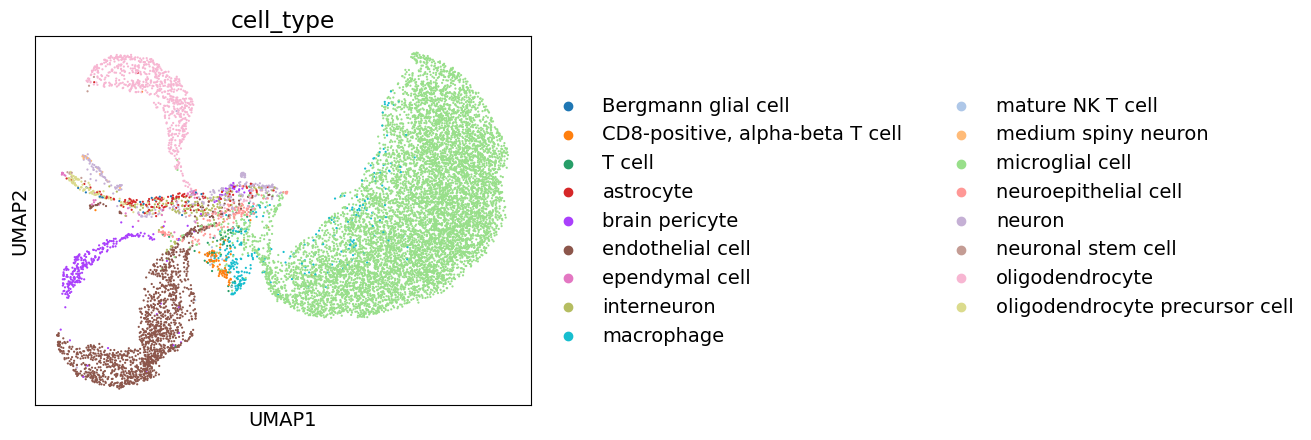

In [53]:
# Step 3: Plot UMAP and color by 'cell_type'
sc.pl.umap(adata, color='cell_type', size=10)

In [59]:
adata.obs.cell_type = adata.obs.cell_type.astype(str)
adata.obs.main_type = adata.obs.cell_type

In [60]:
adata.obs.main_type 

cell_id_index
0            endothelial cell
1                   microglia
2                   microglia
3                   microglia
4                   microglia
                 ...         
12647               microglia
12648               microglia
12649               microglia
12650    neuroepithelial cell
12651               microglia
Name: cell_type, Length: 12652, dtype: object

In [62]:
adata.obs.main_type[adata.obs.cell_type == "microglial cell"] = "microglia"
adata.obs.main_type[~ (adata.obs.cell_type == "microglia")] = "not_microglia"

/scratch/ipykernel_26025/3461908704.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs.main_type[adata.obs.cell_type == "microglial cell"] = "microglia"
/scratch/ipykernel_26025/3461908704.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs.main_type[~ (adata.obs.cell_type == "microglia")] = "not_microglia"


In [66]:
adata.obs

,cell_id,age,batch,cell_type,mouse.id,sex,subtissue,tissue,louvain,leiden
cell_id_index,,,,,,,,,,
0,A10_B000176_B008056_S10,18m,1,not_microglia,18_53_M,male,Cortex,Brain_Non-Myeloid,10,27
1,A10_B000840_S130_L002,24m,1,microglia,24_60_M,male,Striatum,Brain_Myeloid,3,2
2,A10_B000843_S94_L001,24m,1,microglia,24_60_M,male,Hippocampus,Brain_Myeloid,3,2
3,A10_B001060_B009250_S214,18m,1,microglia,18_47_F,female,Cerebellum,Brain_Myeloid,3,2
4,A10_B001061_B009251_S298,18m,1,microglia,18_46_F,female,Cerebellum,Brain_Myeloid,3,2
...,...,...,...,...,...,...,...,...,...,...
12647,P9_B003921_S369_L001,24m,1,microglia,24_59_M,male,Cortex,Brain_Myeloid,3,2
12648,P9_D045315_B008285_S369,18m,1,microglia,18_45_M,male,Hippocampus,Brain_Myeloid,3,2
12649,P9_D045318_B008591_S369,18m,1,microglia,18_45_M,male,Striatum,Brain_Myeloid,3,2


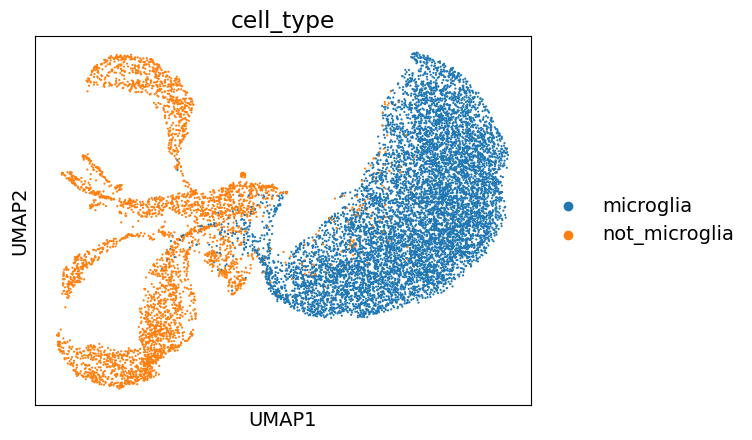

In [67]:
sc.pl.umap(adata, color='cell_type', size=10)